# Chapter 8: Triangle Counting

Triangle counting using A² ⊙ A (element-wise multiply of A-squared with A).

In [1]:
import graphblas as gb
from graphblas import Matrix, Vector, semiring, binary
from graphblas import io as gbio
import networkx as nx
import matplotlib.pyplot as plt
from graph_utils import draw_graph, draw_vector

## Zachary's Karate Club Graph

The karate club graph is a classic social network of 34 members with 78 edges representing friendships.

In [2]:
# Load karate club graph from Matrix Market format
A = gbio.mmread("karate.mtx")
A = A.dup(dtype=int)  # Convert to integer
print(f"Karate club: {A.nrows} nodes, {A.nvals} edges")
print(f"Symmetric: {A.isequal(A.T)}")

Karate club: 34 nodes, 156 edges
Symmetric: True


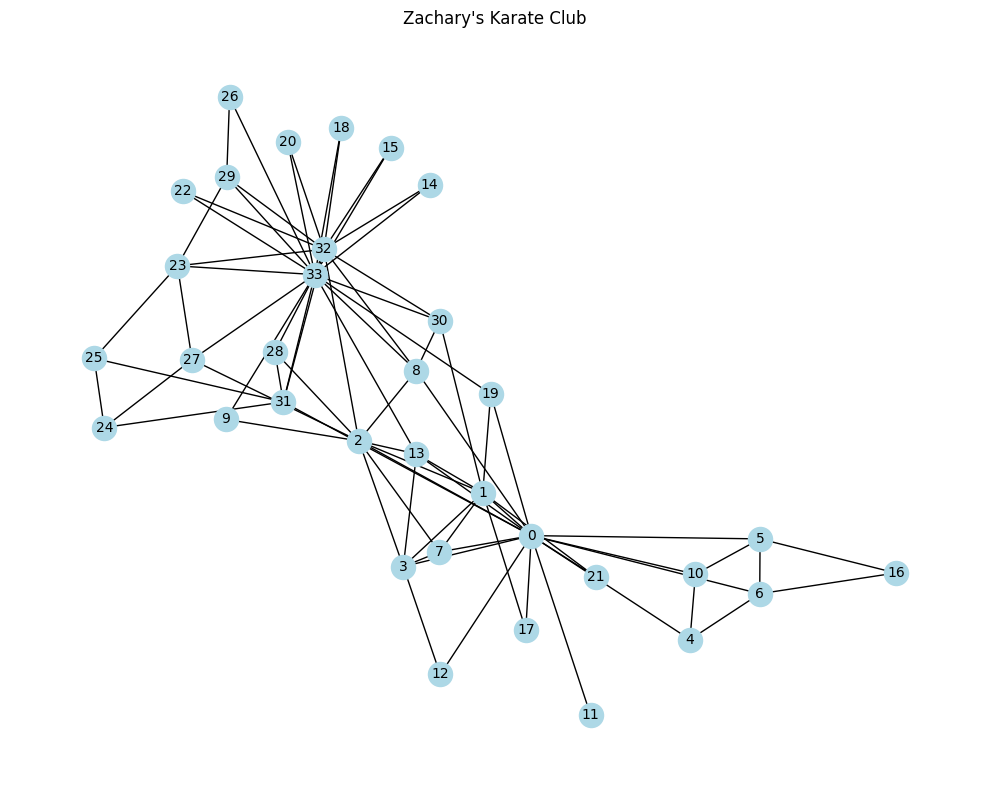

In [3]:
# Build NetworkX graph for visualization
rows, cols, _ = A.to_coo()
G = nx.Graph()
G.add_edges_from(zip(rows, cols))
pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(10, 8))
draw_graph(G, pos=pos, ax=ax, title="Zachary's Karate Club", 
           directed=False, node_size=300, font_size=10, show=False)
plt.tight_layout()
plt.show()

## Triangle Counting: A² ⊙ A

In [4]:
# A² counts 2-hop paths between nodes
A2 = A.mxm(A, semiring.plus_times).new()
print(f"A² has {A2.nvals} non-zero entries (pairs connected by 2-hop paths)")

A² has 698 non-zero entries (pairs connected by 2-hop paths)


In [5]:
# A² ⊙ A: where 2-hop paths AND direct edges exist = triangles
# Each triangle is counted 6 times (once per directed edge, both directions)
triangle_matrix = A2.ewise_mult(A, binary.times).new()
print(f"A² ⊙ A has {triangle_matrix.nvals} non-zero entries")

A² ⊙ A has 134 non-zero entries


In [6]:
# Total triangles = sum(A² ⊙ A) / 6
total = triangle_matrix.reduce_scalar(binary.plus).get()
num_triangles = total // 6
print(f"Total triangles: {num_triangles}")

Total triangles: 45


## Per-Node Triangle Count

In [7]:
# Sum each row: triangles involving each node
# Each triangle counts twice per node (once for each neighbor in the triangle)
node_triangles = triangle_matrix.reduce_rowwise(binary.plus).new()
print(f"Nodes with triangles: {node_triangles.nvals} of {A.nrows}")

Nodes with triangles: 32 of 34


In [8]:
# Divide by 2 for actual count per node
node_triangles_actual = node_triangles.apply(binary.truediv, right=2).new()

# Show nodes with most triangles
indices, values = node_triangles_actual.to_coo()
tri_list = sorted(zip(indices, values), key=lambda x: -x[1])
print("Top 10 nodes by triangle count:")
for node, count in tri_list[:10]:
    print(f"  Node {int(node)}: {int(count)} triangles")

Top 10 nodes by triangle count:
  Node 0: 18 triangles
  Node 33: 15 triangles
  Node 32: 13 triangles
  Node 1: 12 triangles
  Node 2: 11 triangles
  Node 3: 10 triangles
  Node 7: 6 triangles
  Node 13: 6 triangles
  Node 8: 5 triangles
  Node 23: 4 triangles


## Visualizing Triangle Counts

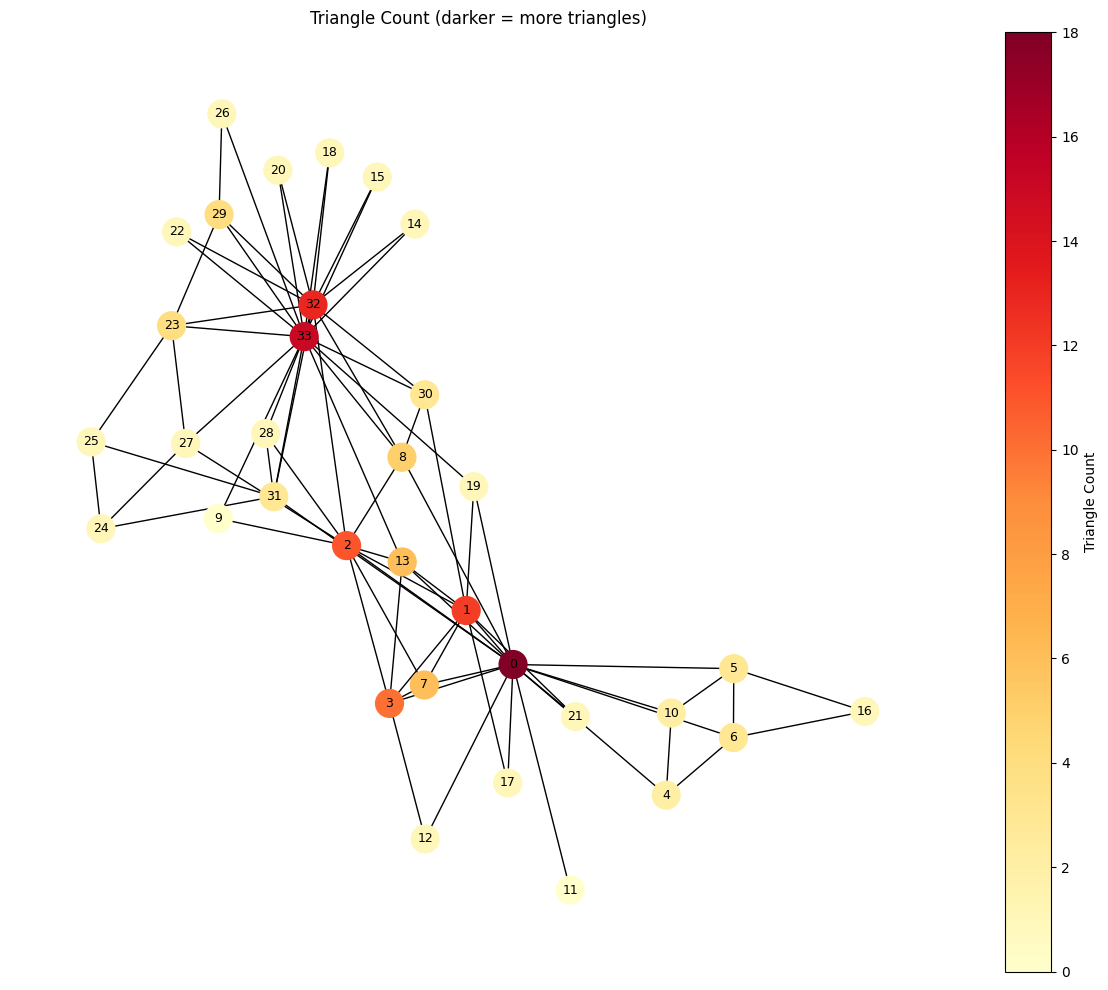

In [9]:
# Visualize triangle counts - nodes in more triangles are darker
fig, ax = plt.subplots(figsize=(12, 10))

# Color nodes by triangle count
indices, values = node_triangles_actual.to_coo()
tri_counts = {int(i): int(v) for i, v in zip(indices, values)}
# Use G.nodes() order to match how nx.draw applies colors
colors = [tri_counts.get(node, 0) for node in G.nodes()]

draw_graph(G, pos=pos, ax=ax, title="Triangle Count (darker = more triangles)",
           node_color=colors, cmap=plt.cm.YlOrRd, node_size=400, 
           font_size=9, directed=False, show=False)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, 
                           norm=plt.Normalize(vmin=min(colors), vmax=max(colors)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Triangle Count')
plt.tight_layout()
plt.show()